In [ ]:
import sys
!"{sys.executable}" -m pip install datasets

In [ ]:
from datasets import get_dataset_config_names
from data

print(get_dataset_config_names("mohanty/PlantVillage"))

In [ ]:
from datasets import load_dataset

# Load the default configuration (color images)
# This automatically downloads the train and test splits.
dataset = load_dataset("mohanty/PlantVillage", "default")

print(dataset)
# DatasetDict({
#     train: Dataset({ features: [...], num_rows: 43596 }),
#     test: Dataset({ features: [...], num_rows: 10709 })
# })


In [1]:
import tensorboard

In [2]:
import sys
import tensorflow as tf

REMOVE DODGY IMAGES

In [3]:
import cv2
from PIL import Image
import os

def what(image_path):
    """Lightweight replacement for the removed `imghdr.what`."""
    try:
        with Image.open(image_path) as img:
            return img.format.lower()
    except Exception:
        return None

In [4]:
data_dir = 'data/raw/apple_color' 

In [5]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [6]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

LOAD DATA

In [7]:
import numpy as np
from matplotlib import pyplot as plt

In [8]:
data = tf.keras.utils.image_dataset_from_directory('data/raw/apple_color')

Found 3171 files belonging to 4 classes.


In [9]:
data_iterator = data.as_numpy_iterator()

In [10]:
batch = data_iterator.next()

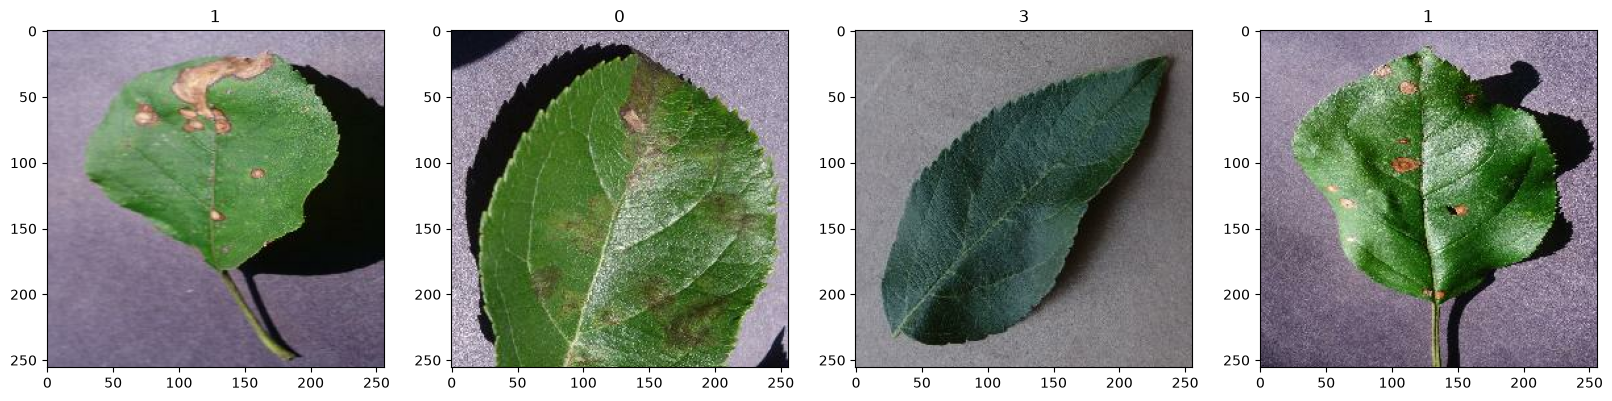

In [11]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

SCALE DATA

In [12]:
data = data.map(lambda x,y: (x/255, y))

In [13]:
data.as_numpy_iterator().next()

(array([[[[0.42352942, 0.40784314, 0.37254903],
          [0.42352942, 0.40784314, 0.37254903],
          [0.42352942, 0.40784314, 0.37254903],
          ...,
          [0.49019608, 0.47058824, 0.45490196],
          [0.4862745 , 0.46666667, 0.4509804 ],
          [0.46666667, 0.44705883, 0.43137255]],
 
         [[0.4509804 , 0.43529412, 0.4       ],
          [0.44313726, 0.42745098, 0.39215687],
          [0.43529412, 0.41960785, 0.38431373],
          ...,
          [0.49803922, 0.47843137, 0.4627451 ],
          [0.49411765, 0.4745098 , 0.45882353],
          [0.47843137, 0.45882353, 0.44313726]],
 
         [[0.46666667, 0.4509804 , 0.41568628],
          [0.45490196, 0.4392157 , 0.40392157],
          [0.4392157 , 0.42352942, 0.3882353 ],
          ...,
          [0.5019608 , 0.48235294, 0.46666667],
          [0.49803922, 0.47843137, 0.4627451 ],
          [0.4862745 , 0.46666667, 0.4509804 ]],
 
         ...,
 
         [[0.53333336, 0.5137255 , 0.5019608 ],
          [0.53333

SPLIT DATA

In [14]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [15]:
train_size


70

In [16]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

START BUILDING THE MODEL

In [17]:
train

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [18]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [32]:
model = Sequential()

In [33]:
model.add(Input(shape=(256,256,3)))
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(4, activation='softmax'))

In [34]:
loss=tf.losses.SparseCategoricalCrossentropy()

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,697,396 (14.10 MB)

 Trainable params: 3,697,396 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

TRAIN

In [39]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
logdir='logs'

In [41]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [42]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 43s 559ms/step - accuracy: 0.6567 - loss: 0.8409 - val_accuracy: 0.8766 - val_loss: 0.3309
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 36s 507ms/step - accuracy: 0.8826 - loss: 0.3252 - val_accuracy: 0.9094 - val_loss: 0.2587
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 36s 511ms/step - accuracy: 0.9103 - loss: 0.2747 - val_accuracy: 0.9219 - val_loss: 0.2169
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 36s 514ms/step - accuracy: 0.9116 - loss: 0.2332 - val_accuracy: 0.9281 - val_loss: 0.2368
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 38s 541ms/step - accuracy: 0.9469 - loss: 0.1650 - val_accuracy: 0.8687 - val_loss: 0.4209
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 557ms/step - accuracy: 0.9612 - loss: 0.1186 - val_accuracy: 0.9234 - val_loss: 0.2102
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 556ms/step - accuracy: 0.9719 - loss: 0.0835 - val_accuracy: 0.9203 - val_loss: 0.2692
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 550ms/step - accuracy: 0.9710 - loss: 0.0859 - val_accu

PLOT PERFORMANCE

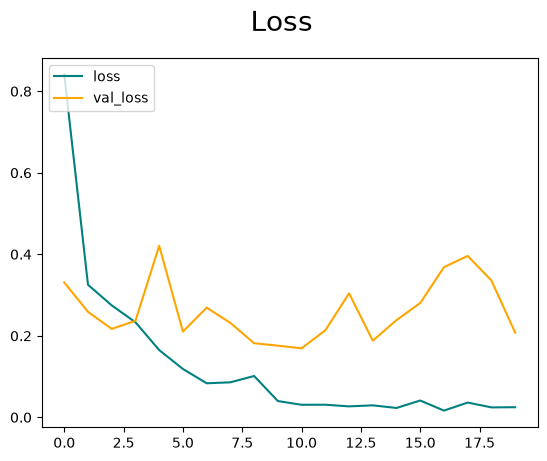

In [43]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

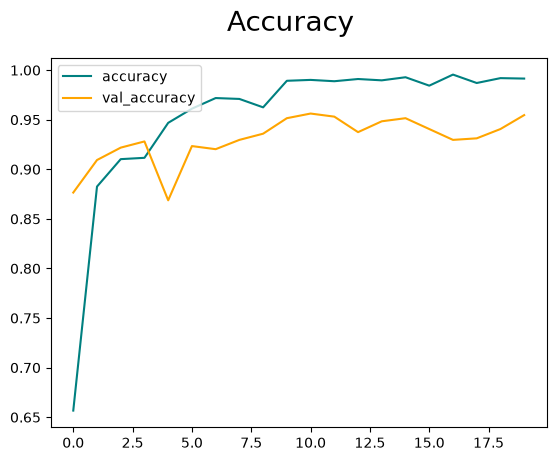

In [44]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

EVALUATE

In [46]:
from tensorflow.keras.metrics import SparseCategoricalAccuracy

acc = SparseCategoricalAccuracy()

In [48]:
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


In [49]:
print(acc.result())

tf.Tensor(0.9347079, shape=(), dtype=float32)


SAVE MODEL

In [50]:
from tensorflow.keras.models import load_model

In [51]:
os.makedirs('models', exist_ok=True)
model.save(os.path.join('models', 'imageclassifier.keras'))

In [52]:
new_model = load_model(os.path.join('models', 'imageclassifier.keras'))

In [53]:
new_model.predict(np.expand_dims(resize/255, 0))

NameError: name 'resize' is not defined